<a href="https://colab.research.google.com/github/leman-cap13/Machine_Learning/blob/main/Unsupervised_learning_material.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unsupervised learning

Unsupervised Learning is a type of machine learning where the model works without labelled data. It learns patterns on its own by grouping similar data points or finding hidden structures without any human intervention.

It is used for tasks like clustering, dimensionality reduction and Association Rule Learning.
Helps identify hidden patterns in data
Useful for grouping, compression and anomaly detection

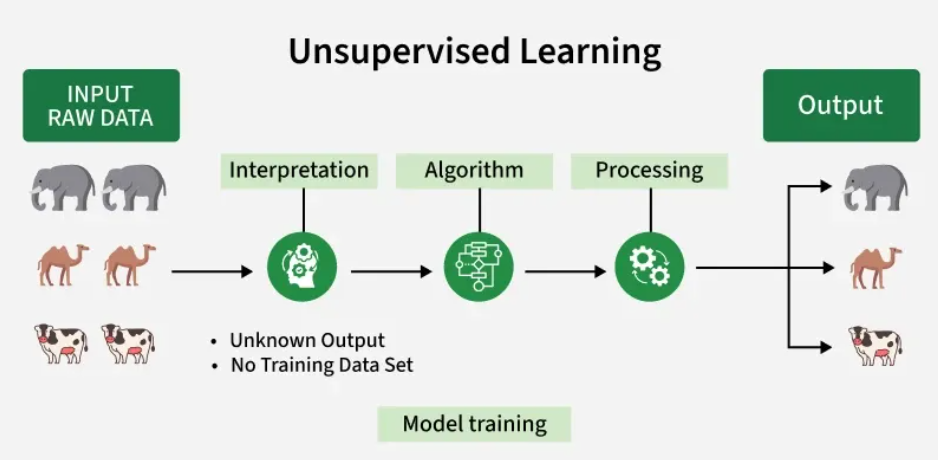

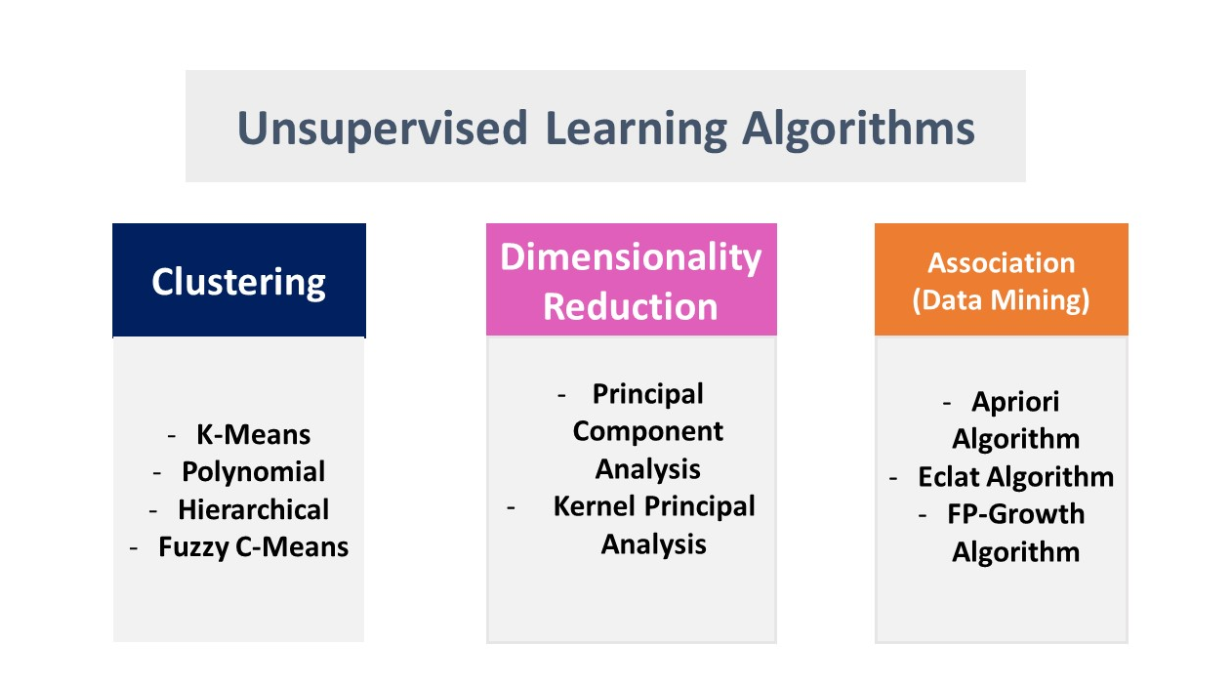

#Clustering

Clustering is an unsupervised machine learning technique that groups similar data points together into clusters based on their characteristics, without using any labeled data. The objective is to ensure that data points within the same cluster are more similar to each other than to those in different clusters, enabling the discovery of natural groupings and hidden patterns in complex datasets.

The clustering Algorithms are of many types.


Distribution-based methods:

It is a clustering model in which we will fit the data on the probability that how it may belong to the same distribution. The grouping done may be normal or gaussian. Gaussian distribution is more prominent where we have a fixed number of distributions and all the upcoming data is fitted into it such that the distribution of data may get maximized. This result in grouping is shown in the figure:

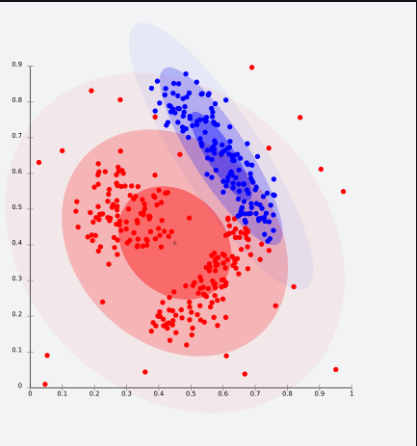

Centroid-based methods:

This is basically one of the iterative clustering algorithms in which the clusters are formed by the closeness of data points to the centroid of clusters. Here, the cluster center i.e. centroid is formed such that the distance of data points is minimum with the center. This problem is basically one of the NP-Hard problems and thus solutions are commonly approximated over a number of trials.

For Ex- K - means algorithm is one of the popular examples of this algorithm. The biggest problem with this algorithm is that we need to specify K in advance. It also has problems in clustering density-based distributions

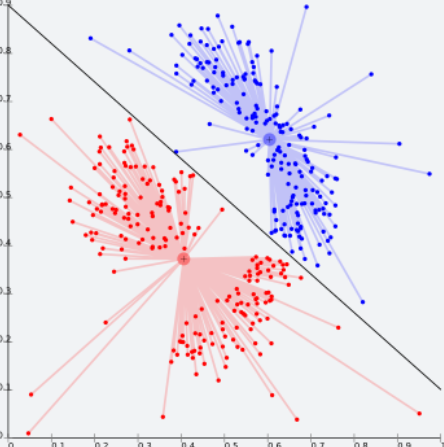

Connectivity based methods :

The core idea of the connectivity-based model is similar to Centroid based model which is basically defining clusters on the basis of the closeness of data points. Here we work on a notion that the data points which are closer have similar behavior as compared to data points that are farther.
It is not a single partitioning of the data set, instead, it provides an extensive hierarchy of clusters that merge with each other at certain distances. Here the choice of distance function is subjective. These models are very easy to interpret but it lacks scalability.

For Ex- hierarchical algorithm and its variants.

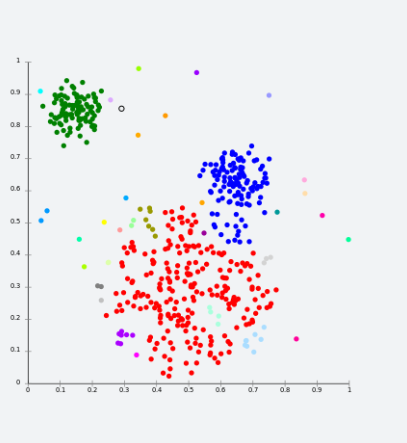

Density Models:

In this clustering model, there will be searching of data space for areas of the varied density of data points in the data space. It isolates various density regions based on different densities present in the data space.
For Ex- DBSCAN and OPTICS.

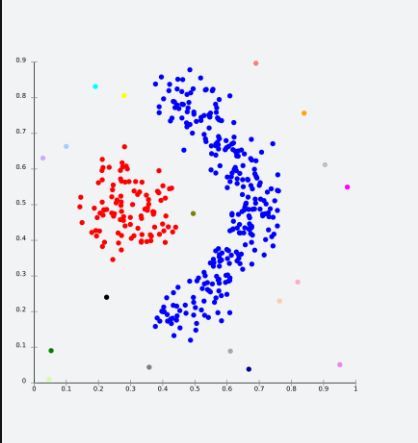

#K-MEANS CLUSTERING

K-Means Clustering groups similar data points into clusters without needing labeled data. It is used to uncover hidden patterns when the goal is to organize data based on similarity.

Helps identify natural groupings in unlabeled datasets
Works by grouping points based on distance to cluster centers
Commonly used in customer segmentation, image compression, and pattern discovery
Useful when you need structure from raw, unorganized data

The algorithm will categorize the items into "
k
k" groups or clusters of similarity. To calculate that similarity we will use the Euclidean distance as a measurement. The algorithm works as follows:  

1. Initialization: We begin by randomly selecting k cluster centroids.

2. Assignment Step: Each data point is assigned to the nearest centroid, forming clusters.

3. Update Step: After the assignment, we recalculate the centroid of each cluster by averaging the points within it.

4. Repeat: This process repeats until the centroids no longer change or the maximum number of iterations is reached

K-means clustering is an iterative process to minimize the sum of distances between the data points and their cluster centroids.

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lmanqasml","key":"2d851a4eb9cae06770577185722326e0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d shwetabh123/mall-customers


Dataset URL: https://www.kaggle.com/datasets/shwetabh123/mall-customers
License(s): CC0-1.0
  0% 0.00/1.56k [00:00<?, ?B/s]
100% 1.56k/1.56k [00:00<00:00, 5.29MB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/mall-customers.zip', 'r')
zip_ref.extractall()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score



In [ ]:
df=pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]] # pick 2 features for 2D visualization to see how it looks
# K-Means uses  Eucliden distance, and  if i select categorical feature lik gender "Male"/"Female"... it  has no numeric distance.
#We’ll use Gender later for analysis

#Euclidean distance is the standard metric used to measure how close data points are to cluster centers (centroids).
#It's the straight-line, "as the crow flies" distance, calculated as the square root of the sum of squared differences
#between corresponding coordinates of two points, used to assign each point to its nearest centroid and iteratively update centroids
#until clusters stabilize.

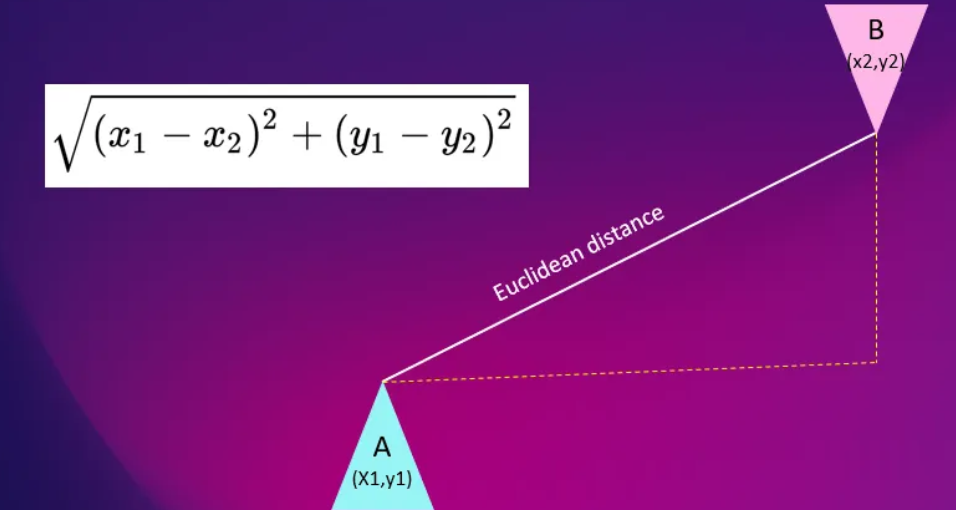

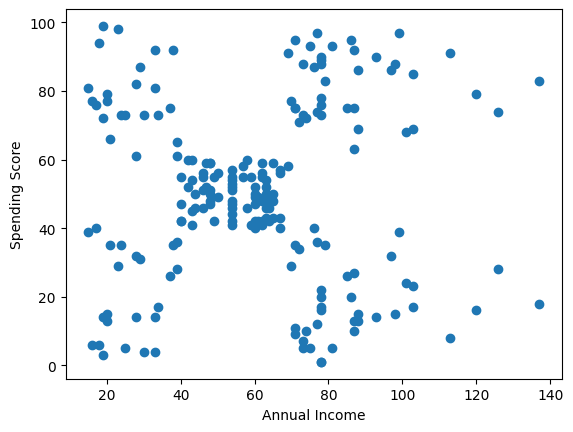

In [ ]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


In [ ]:
#CENTROID


# The K-means clustering algorithm relies on centroids to establish clusters.
#In simple terms, a centroid, when applied to a set of points in a two-dimensional X-Y plane, becomes another point characterized by
#its X and Y coordinates. For instance, given three points with coordinates (X1, Y1), (X2, Y2), and (X3, Y3),
#the centroid of these points can be computed as the average of their X and Y coordinates:

# Centroid = ((X1 + X2 + X3) / 3, (Y1 + Y2 + Y3) / 3)

# This formula can be extended to encompass n points as follows:

# Centroid = ((X1 + X2 + … + Xn) / n, (Y1 + Y2 + … + Yn) / n)

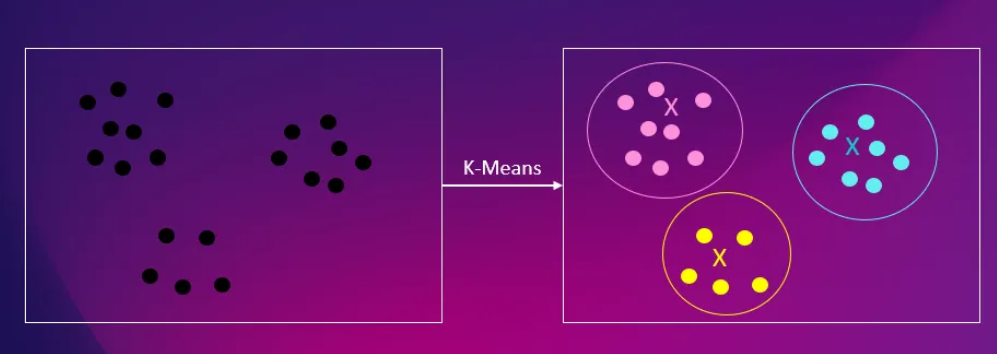

In [ ]:
#Scaling
#K-Means only knows one thing: distance between points  so we need to scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
inertias = []
Ks = range(1, 11)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")  # auto => runs the algorithm multiple times with different random starts
    km.fit(X_scaled)
    inertias.append(km.inertia_)


In [ ]:
#Lower inertia means:
# points are close to centers
# tight clusters

# Higher inertia means:
# points are far away
# messy clusters

#inertia always decreases when K increases

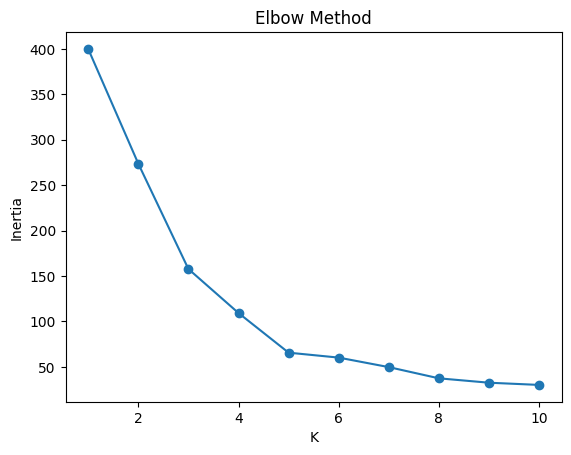

In [ ]:
plt.plot(Ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [ ]:
print("Cluster centers:")
print(km.cluster_centers_)  # show me the centers

print("\nLabels (first 10):")
print(km.labels_[:10])  # my labels

print("\nInertia:")
print(km.inertia_)


Cluster centers:
[[ 0.07722948 -0.11290604]
 [ 1.39436395  1.39334111]
 [ 0.73205646 -1.42897101]
 [-1.35921337  1.19570407]
 [-1.37320883 -1.57680239]
 [ 0.62597864  1.18793976]
 [-0.55987331  0.08456805]
 [ 1.87564575 -1.09476801]
 [-1.23585672 -0.65714315]
 [ 2.56142316  1.10512043]]

Labels (first 10):
[8 3 4 3 8 3 4 3 4 3]

Inertia:
30.05932269404222


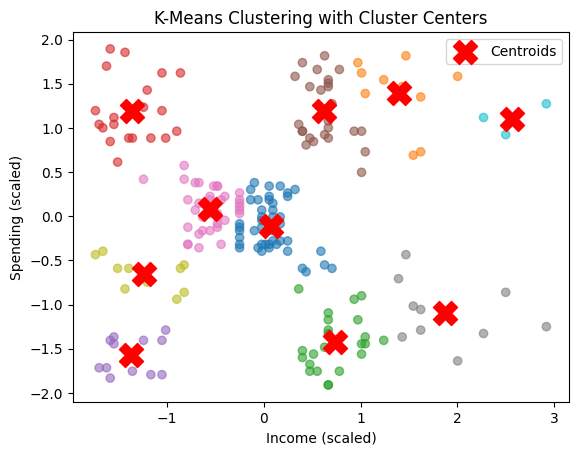

In [ ]:
import matplotlib.pyplot as plt

# scatter plot of all customers
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=km.labels_,
    cmap="tab10",
    alpha=0.6
)

# plot cluster centers
plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    c="red",
    s=300,
    marker="X",
    label="Centroids"
)

plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")
plt.title("K-Means Clustering with Cluster Centers")
plt.legend()
plt.show()


In [ ]:
#K-Means finds centers, then assigns points to the nearest center
# Elbow is for choosing K, but it’s not enough.
# Silhouette exists to fix what Elbow cannot see.
#elbow use for
# How close are points to their own cluster center?

#Silouette use for
#Is this point closer to its own cluster than to other clusters?

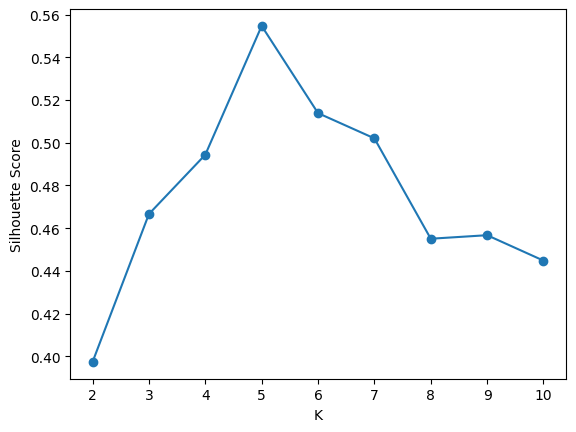

In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):  # silhouette needs at least 2 clusters
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)


plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

#Higher silhouette score = better clustering

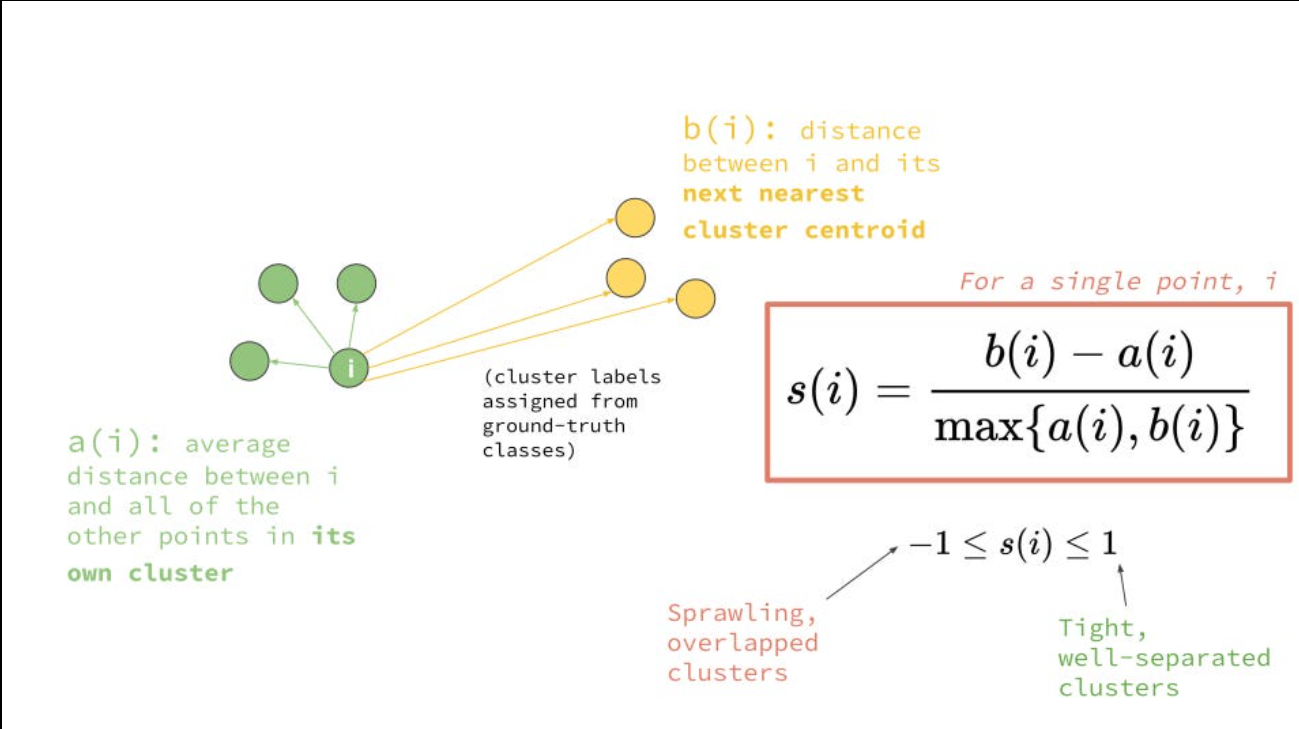

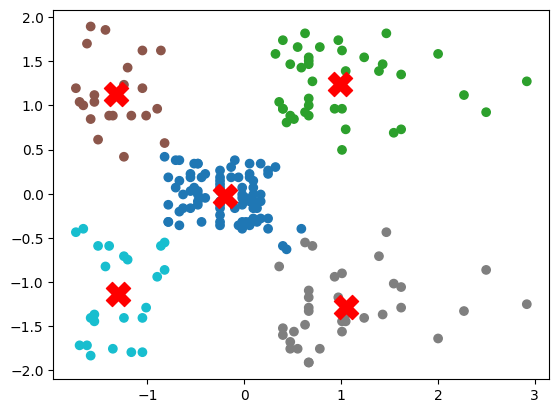

In [ ]:
# after ffinding best k make final model
km = KMeans(n_clusters=5, random_state=42)
labels = km.fit_predict(X_scaled)


plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="tab10")
plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    c="red",
    s=300,
    marker="X"
)
plt.show()


In [ ]:
labels = km.labels_
centers = km.cluster_centers_
score = silhouette_score(X_scaled, labels)

In [ ]:
score

np.float64(0.5546571631111091)

In [ ]:
centers

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [ ]:
centers_original = scaler.inverse_transform(km.cluster_centers_)
centers_original
# real data value before scaled

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [ ]:
df["cluster"] = labels


In [ ]:
df.groupby("cluster")["Genre"].value_counts().reset_index(name="count")



,cluster,Genre,count
0,0,Female,48
1,0,Male,33
2,1,Female,21
3,1,Male,18
4,2,Female,13
5,2,Male,9
6,3,Male,19
7,3,Female,16
8,4,Female,14
9,4,Male,9


In [ ]:
df.groupby("cluster")["Age"].mean()

,Age
cluster,
0,42.716049
1,32.692308
2,25.272727
3,41.114286
4,45.217391


In [ ]:
df["cluster"].value_counts()


,count
cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
# lest test our model
import pandas as pd

new_customer = pd.DataFrame({
    "Annual Income (k$)": [60],
    "Spending Score (1-100)": [40]
})


new_customer_scaled = scaler.transform(new_customer)


In [ ]:
cluster_id = km.predict(new_customer_scaled)
cluster_id


array([0], dtype=int32)

#DBSCAN CLUSTERING

DBSCAN is a density-based clustering algorithm that groups data points that are closely packed together and marks outliers as noise based on their density in the feature space. It identifies clusters as dense regions in the data space separated by areas of lower density. Unlike K-Means or hierarchical clustering which assumes clusters are compact and spherical, DBSCAN perform well in handling real-world data irregularities such as:

Arbitrary-Shaped Clusters: Clusters can take any shape not just circular or convex.
Noise and Outliers: It effectively identifies and handles noise points without assigning them to any cluster.

Key Parameters in DBSCAN
1. eps: This defines the radius of the neighborhood around a data point. If the distance between two points is less than or equal to eps they are considered neighbors. A common method to determine eps is by analyzing the k-distance graph. Choosing the right eps is important:

If eps is too small most points will be classified as noise.
If eps is too large clusters may merge and the algorithm may fail to distinguish between them.


2. MinPts: This is the minimum number of points required within the eps radius to form a dense region. A general rule of thumb is to set MinPts >= D+1 where D is the number of dimensions in the dataset.

For most cases a minimum value of MinPts = 3 is recommended.

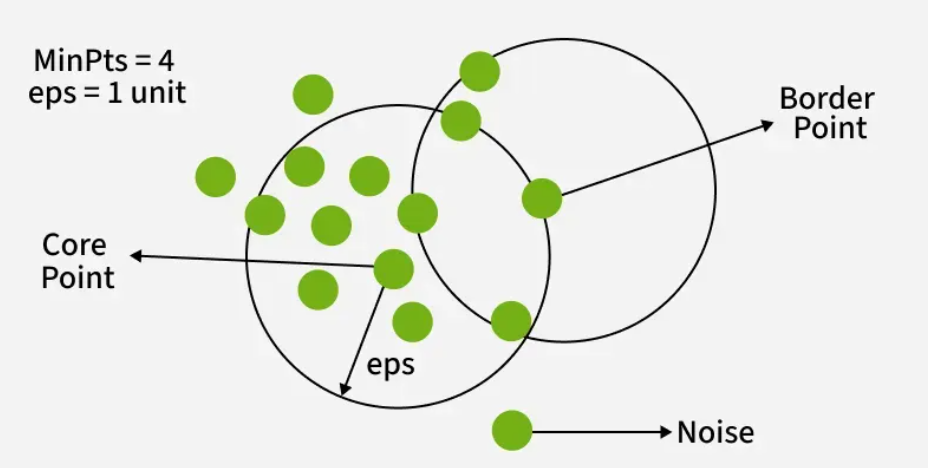

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.4,
    min_samples=4
)

db_labels = db.fit_predict(X_scaled)


In [ ]:
set(db_labels)

#0,1,2 → clusters

# -1 → NOISE (outlier)


{np.int64(-1), np.int64(0), np.int64(1), np.int64(2)}

In [ ]:
db_labels

array([ 0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  2,  1,  2,  1,  0,  1,  2,  1,
        2,  1,  2,  1,  2,  1,  0,  1,  2,  1,  0,  1,  2,  1,  2,  1,  2,
        1,  2,  1,  2,  1,  2,  1,  0,  1,  2,  1,  2,  1,  2,  1,  2,  1,
        2,  1,  2,  1,  2,  1,  2,  1,  2,  1,  2,  1,  2,  1, -1,  1,  2,
       -1,  2,  1,  2, -1, -1, -1, -1, -1, -1, -1, -1, -1])

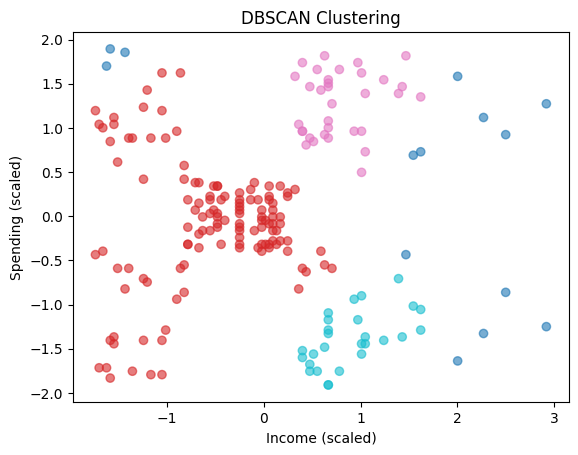

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=db_labels,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")
plt.title("DBSCAN Clustering")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

mask = db_labels != -1  # beacuse it doesnt calculate noise (-1)

if len(set(db_labels[mask])) > 1:
    db_silhouette = silhouette_score(X_scaled[mask], db_labels[mask])
    print(db_silhouette)
else:
    print("Not enough clusters for silhouette")


0.45757015654927535


In [ ]:
df["db_cluster"] = db_labels
df["db_cluster"].value_counts()


,count
db_cluster,
0,126
1,33
2,27
-1,14


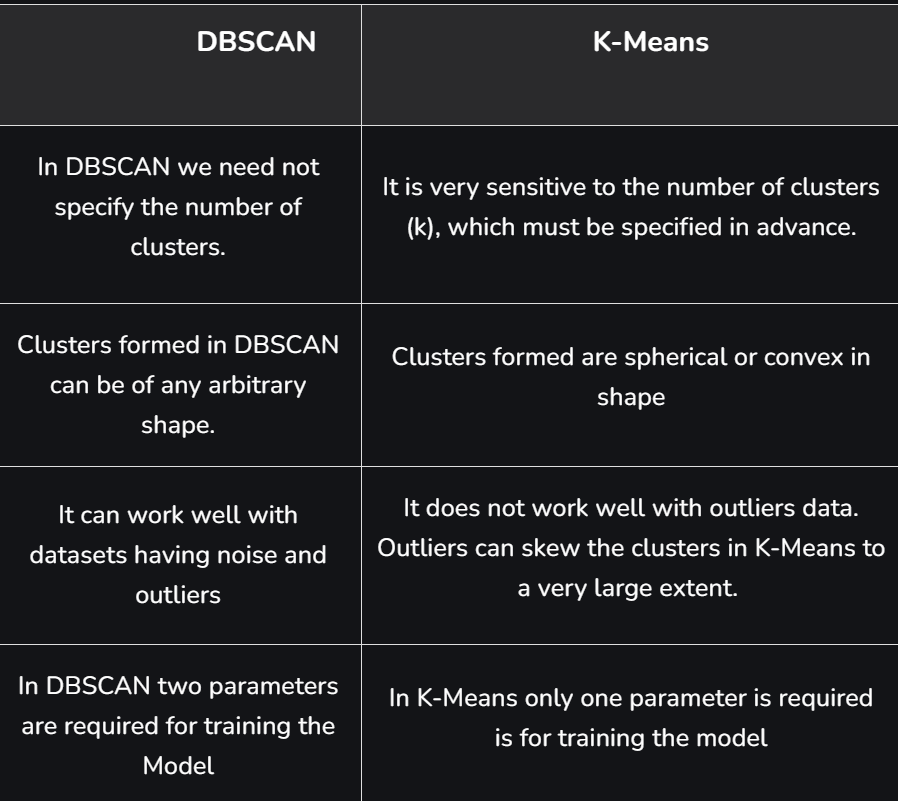

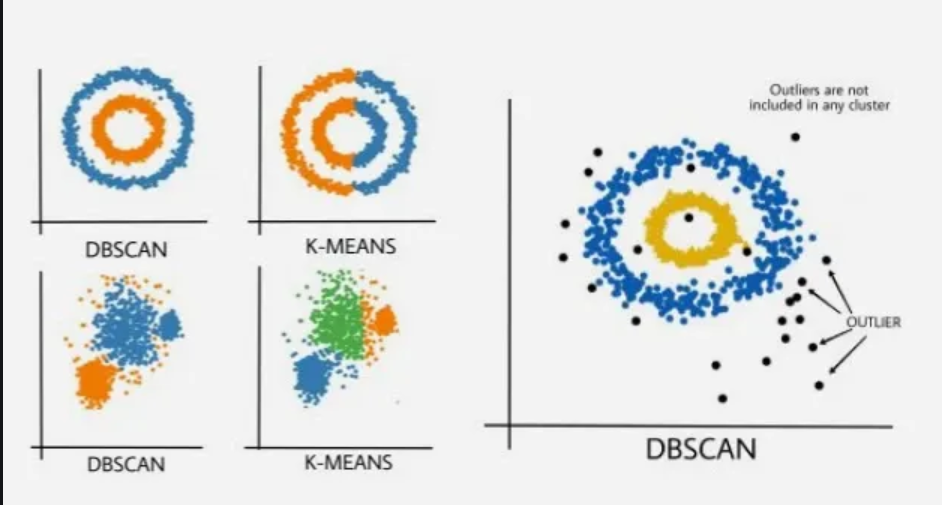

As it can identify clusters of arbitrary shapes and effectively handle noise. K-Means on the other hand is better suited for data with well-defined, spherical clusters and is less effective with noise or complex cluster structures.

#Hierarchical clustering

Hierarchical Clustering is an unsupervised learning method used to group similar data points into clusters based on their distance or similarity. Instead of choosing the number of clusters in advance, it builds a tree-like structure called a dendrogram that shows how clusters merge or split at different levels. It helps identify natural groupings in data and is commonly used in pattern recognition, customer segmentation, gene analysis and image grouping.

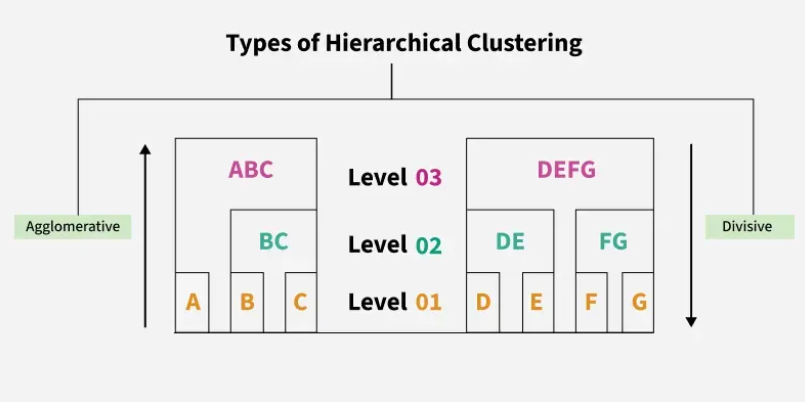

There are two main types of hierarchical clustering.

Agglomerative Clustering

Divisive clustering

1. Hierarchical Agglomerative Clustering

It is also known as the bottom-up approach or hierarchical agglomerative clustering (HAC). Bottom-up algorithms treat each data as a singleton cluster at the outset and then successively agglomerate pairs of clusters until all clusters have been merged into a single cluster that contains all data.

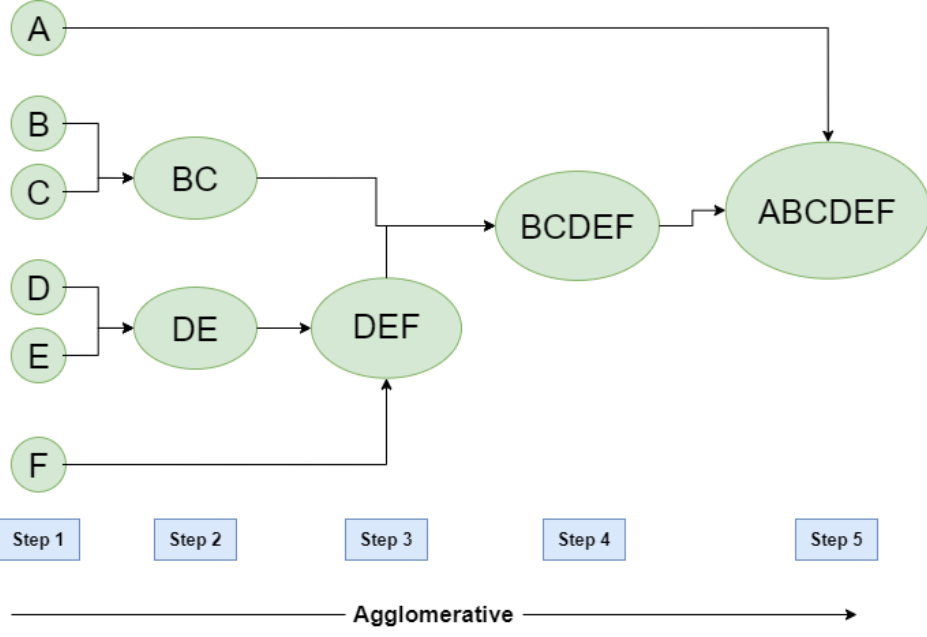

Workflow for Hierarchical Agglomerative clustering
Start with individual points: Each data point is its own cluster. For example if we have 5 data points we start with 5 clusters each containing just one data point.
Calculate distances between clusters: Calculate the distance between every pair of clusters. Initially since each cluster has one point this is the distance between the two data points.
Merge the closest clusters: Identify the two clusters with the smallest distance and merge them into a single cluster.
Update distance matrix: After merging we now have one less cluster. Recalculate the distances between the new cluster and the remaining clusters.
Repeat steps 3 and 4: Keep merging the closest clusters and updating the distance matrix until we have only one cluster left.
Create a dendrogram: As the process continues we can visualize the merging of clusters using a tree-like diagram called a dendrogram. It shows the hierarchy of how clusters are merged.

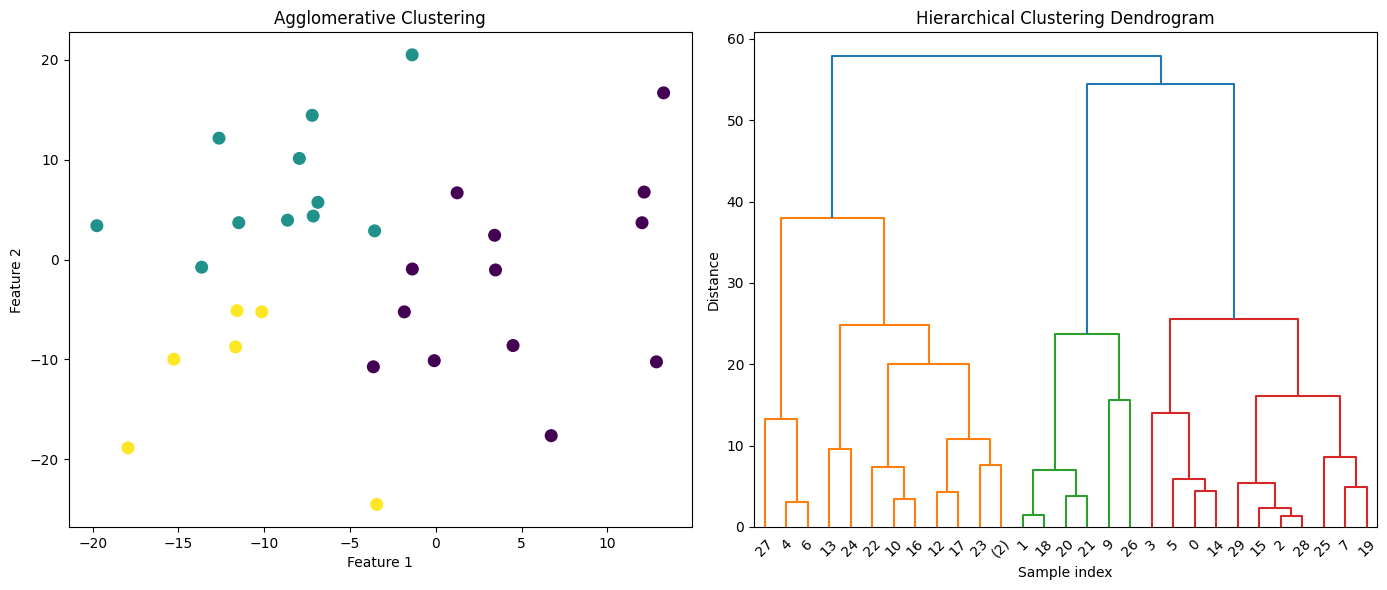

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

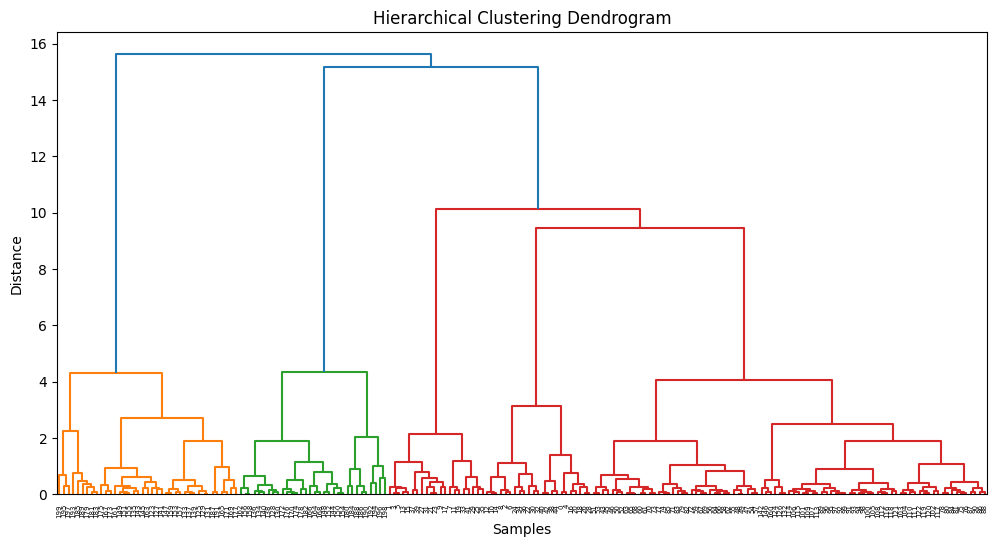

In [ ]:
# in out dataset
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


In [ ]:
#Bu şəkil data-nın necə tədricən birləşdiyini göstərən bir DENDROGRAM
#X-axis (Samples) Aşağıdakı çoxlu xırda yazılar → müştərilər (nöqtələr)

#Y-axis (Distance) Birləşmə məsafəsi Nə qədər yuxarıda birləşibsə → o qədər fərqlidirlər

#Dendrogram-ı yan budaqlarla yox,şaquli uzun xətlərlə oxunur bu sekilde ..Qızıl qayda:

# yuxarıda çox uzun boşluqlar var  aşağıda isə çox xırda birləşmələr

#  Aşağıdakılar:
# çox oxşardır
# tez birləşir

#  Yuxarıdakılar:
# çox fərqlidir
# gec birləşir

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hc_labels = hc.fit_predict(X_scaled)
hc_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

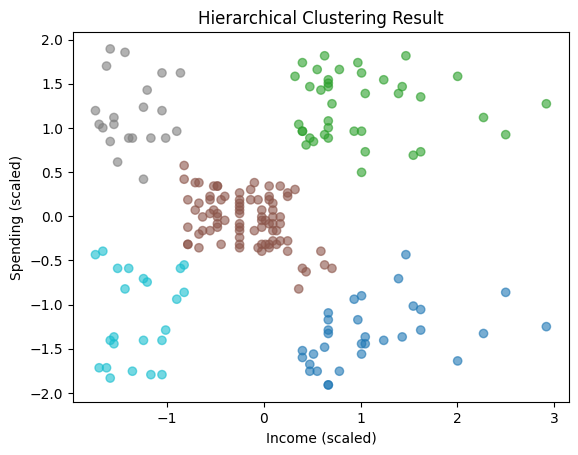

In [ ]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=hc_labels,
    cmap="tab10",
    alpha=0.6
)
plt.title("Hierarchical Clustering Result")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")
plt.show()


2. Hierarchical Divisive clustering

Divisive clustering is also known as a top-down approach. Top-down clustering requires a method for splitting a cluster that contains the whole data and proceeds by splitting clusters recursively until individual data have been split into singleton clusters.

Workflow for Hierarchical Divisive clustering :
Start with all data points in one cluster: Treat the entire dataset as a single large cluster.
Split the cluster: Divide the cluster into two smaller clusters. The division is typically done by finding the two most dissimilar points in the cluster and using them to separate the data into two parts.
Repeat the process: For each of the new clusters, repeat the splitting process: Choose the cluster with the most dissimilar points and split it again into two smaller clusters.
Stop when each data point is in its own cluster: Continue this process until every data point is its own cluster or the stopping condition (such as a predefined number of clusters) is met.

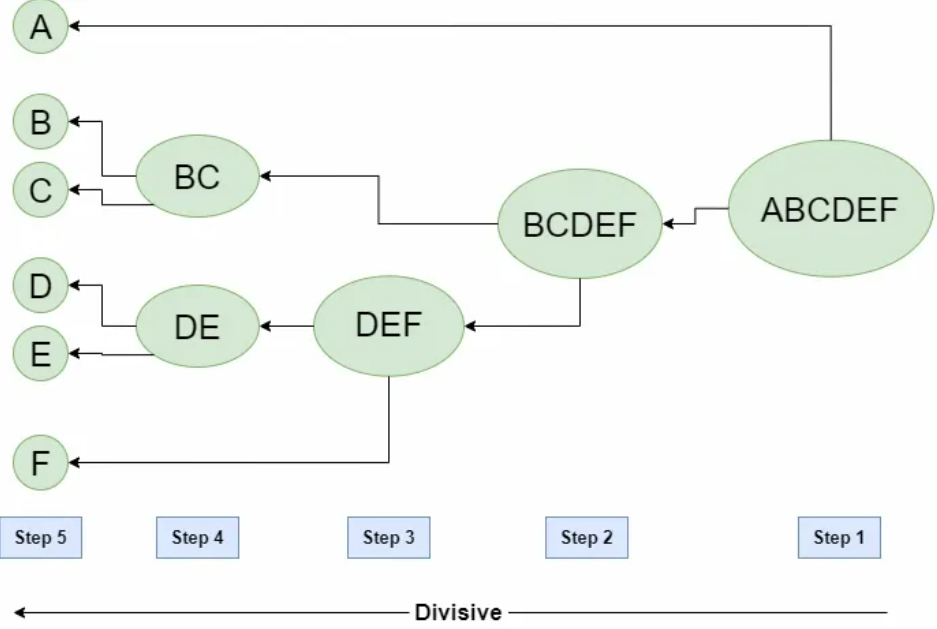

In [ ]:
import numpy as np
from sklearn.cluster import KMeans

def divisive_clustering(X, target_k=5, random_state=42):

    clusters = [{
        "indices": np.arange(len(X)),
        "data": X
    }]

    while len(clusters) < target_k:

        sizes = [len(c["data"]) for c in clusters]
        largest_idx = np.argmax(sizes)


        largest_cluster = clusters.pop(largest_idx)


        km = KMeans(n_clusters=2, random_state=random_state)
        labels = km.fit_predict(largest_cluster["data"])

        for lab in [0, 1]:
            mask = labels == lab
            clusters.append({
                "indices": largest_cluster["indices"][mask],
                "data": largest_cluster["data"][mask]
            })


    final_labels = np.empty(len(X), dtype=int)
    for i, c in enumerate(clusters):
        final_labels[c["indices"]] = i

    return final_labels


In [ ]:
div_labels = divisive_clustering(X_scaled, target_k=5)

df["div_cluster"] = div_labels
df["div_cluster"].value_counts()


,count
div_cluster,
2,50
0,43
4,37
3,36
1,34


In [ ]:
# K-Means
labels_km = km.labels_

# Divisive
div_labels = divisive_clustering(X_scaled, target_k=5)


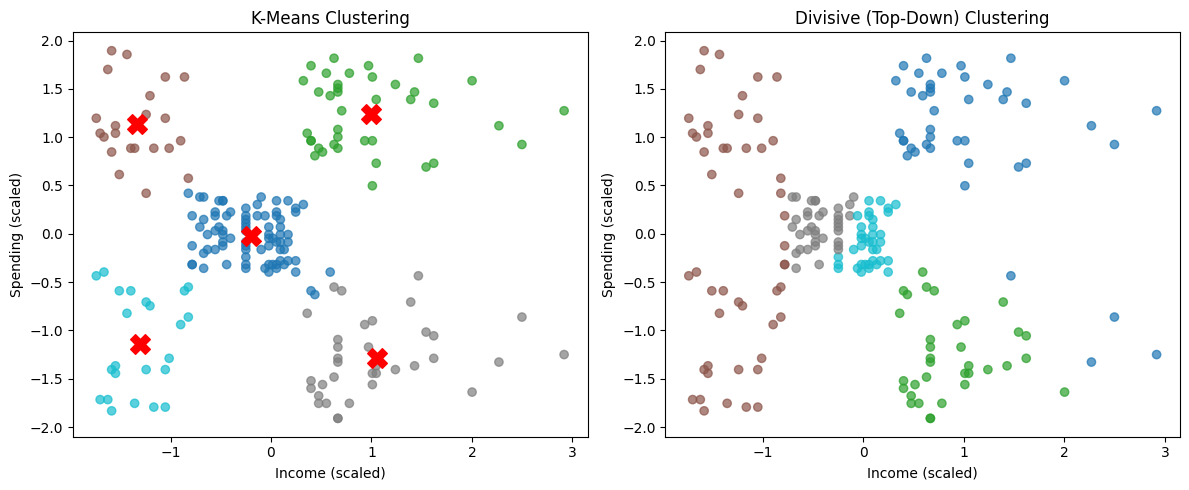

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# -------- K-MEANS --------
plt.subplot(1, 2, 1)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_km,
    cmap="tab10",
    alpha=0.7
)
plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    c="red",
    s=200,
    marker="X"
)
plt.title("K-Means Clustering")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")

# -------- DIVISIVE --------
plt.subplot(1, 2, 2)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=div_labels,
    cmap="tab10",
    alpha=0.7
)
plt.title("Divisive (Top-Down) Clustering")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")

plt.tight_layout()
plt.show()


Computing Distance Matrix
While merging two clusters we check the distance between two every pair of clusters and merge the pair with the least distance/most similarity. But the question is how is that distance determined. There are different ways of defining Inter Cluster distance/similarity. Some of them are:

Min Distance: Find the minimum distance between any two points of the cluster.
Max Distance: Find the maximum distance between any two points of the cluster.
Group Average: Find the average distance between every two points of the clusters.
Ward's Method: The similarity of two clusters is based on the increase in squared error when two clusters are merged.

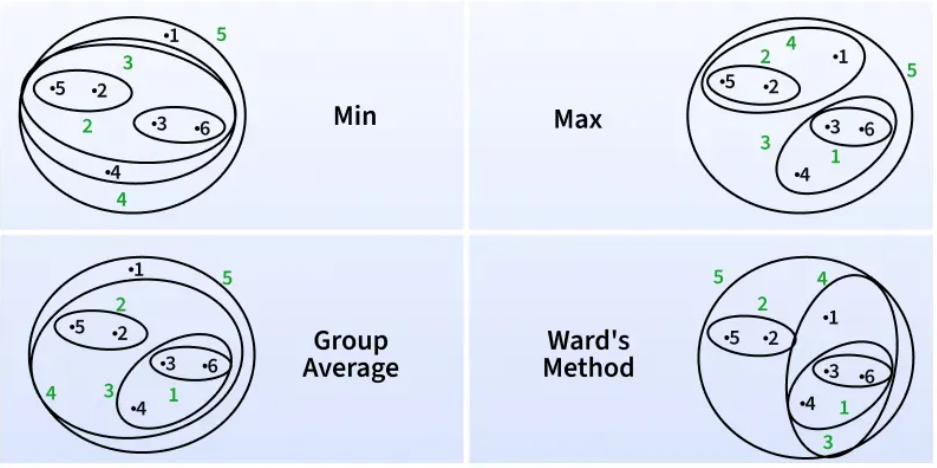

# kaggle dataset

In [ ]:
#  https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

# bunu isleyersiz helelik ele bu colaba sonra Dimensionality Reduction. tiplerini  =>  PSA TSNE UMAP  elave edecem 😊